In [83]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================
# 1. Load and Prep Data
# ==========================================
# Assuming your CSV has a header like: "Dataset, Model_A, Model_B, Model_C, Model_D"
# And the first column is the dataset name.
pp = Path('./CW_1x5_Dynamic_Complete/20251212-182251')
df_train = pd.read_csv(pp / 'simple_accuracy_table_training.txt', index_col=0)
df_test = pd.read_csv(pp / 'simple_accuracy_table_testing.txt', index_col=0)

# PREVIEW: Check if data looks right
print("Raw Accuracy Scores (First 5 rows):")
display(df_test.head())

Raw Accuracy Scores (First 5 rows):


,gb_accuracy,bb_accuracy,hybrid_accuracy_no_reject,hybrid_accuracy_w_reject
dataset,,,,
bench,0.703857,0.838810,0.810810,0.829124
gamma,0.817024,0.882723,0.872681,0.907021
brst-w,0.927932,0.963089,0.960282,0.976947
parkns,0.868684,0.921053,0.911842,0.930132
blood,0.784486,0.786912,0.785845,0.843753


                           meanrank    median       mad  ci_lower  ci_upper  \
gb_accuracy                3.866667  0.905167   0.06084  0.796138  0.970905   
hybrid_accuracy_no_reject  2.566667  0.951991  0.036696  0.874987   0.99422   
hybrid_accuracy_w_reject   1.800000  0.972647  0.021672  0.895126  0.994771   
bb_accuracy                1.766667  0.972298  0.027702  0.915321       1.0   

                          effect_size   magnitude effect_size_above  \
gb_accuracy                       0.0  negligible               0.0   
hybrid_accuracy_no_reject    -0.62863      medium          -0.62863   
hybrid_accuracy_w_reject    -0.996642       large         -0.462328   
bb_accuracy                 -0.957895       large          0.009462   

                          magnitude_above  
gb_accuracy                    negligible  
hybrid_accuracy_no_reject          medium  
hybrid_accuracy_w_reject            small  
bb_accuracy                    negligible  
The statistical analysis was

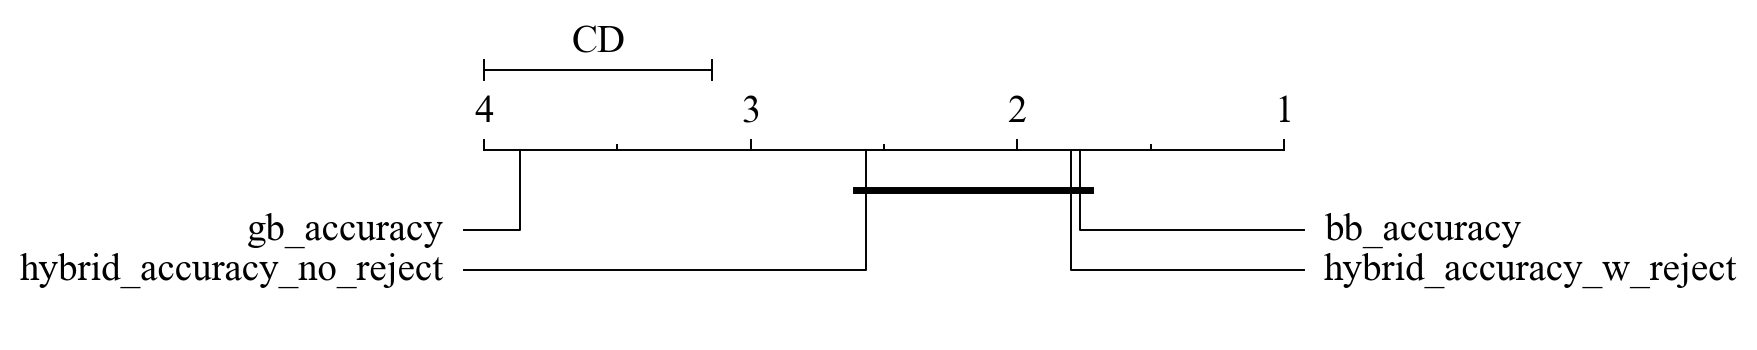

\begin{table}[h]
\centering
\begin{tabular}{lrrllll}
\toprule
 & MR & MED & MAD & CI & $\gamma$ & Magnitude \\
\midrule
gb_accuracy & 3.867 & 0.905 & 0.061 & [0.796, 0.971] & 0.000 & negligible \\
hybrid_accuracy_no_reject & 2.567 & 0.952 & 0.037 & [0.875, 0.994] & -0.629 & medium \\
hybrid_accuracy_w_reject & 1.800 & 0.973 & 0.022 & [0.895, 0.995] & -0.997 & large \\
bb_accuracy & 1.767 & 0.972 & 0.028 & [0.915, 1.000] & -0.958 & large \\
\bottomrule
\end{tabular}
\caption{Summary of populations}
\label{tbl:stat_results}
\end{table}
None


In [84]:
from autorank import autorank, plot_stats, create_report, latex_table
from matplotlib import rcParams

rcParams['font.family'] = 'Times New Roman'
# Run the full statistical suite
# result object contains all the p-values and CD calculations automatically
result = autorank(df_train, alpha=0.05, verbose=False)

# 1. Print a report (so you can copy-paste to your advisor)
create_report(result)

# 2. Plot the CD diagram
plot_stats(result)
plt.show()

# 3. BONUS: It even generates the LaTeX table for your paper
print(latex_table(result))

                               meanrank    median       mad  ci_lower  \
Decision Tree (3.97)           3.966667  0.852532  0.065566  0.735763   
Hybrid, Without Reject (2.75)  2.750000  0.881876  0.059737   0.81081   
XGBoost (1.92)                 1.916667  0.907604  0.059587  0.833548   
Hybrid, With Reject (1.37)     1.366667  0.928320  0.049119  0.843753   

                               ci_upper effect_size   magnitude  \
Decision Tree (3.97)           0.954377         0.0  negligible   
Hybrid, Without Reject (2.75)  0.972704   -0.315574       small   
XGBoost (1.92)                  0.97391   -0.592922      medium   
Hybrid, With Reject (1.37)     0.989324   -0.882427       large   

                              effect_size_above magnitude_above  
Decision Tree (3.97)                        0.0      negligible  
Hybrid, Without Reject (2.75)         -0.315574           small  
XGBoost (1.92)                        -0.290853           small  
Hybrid, With Reject (1.37)        

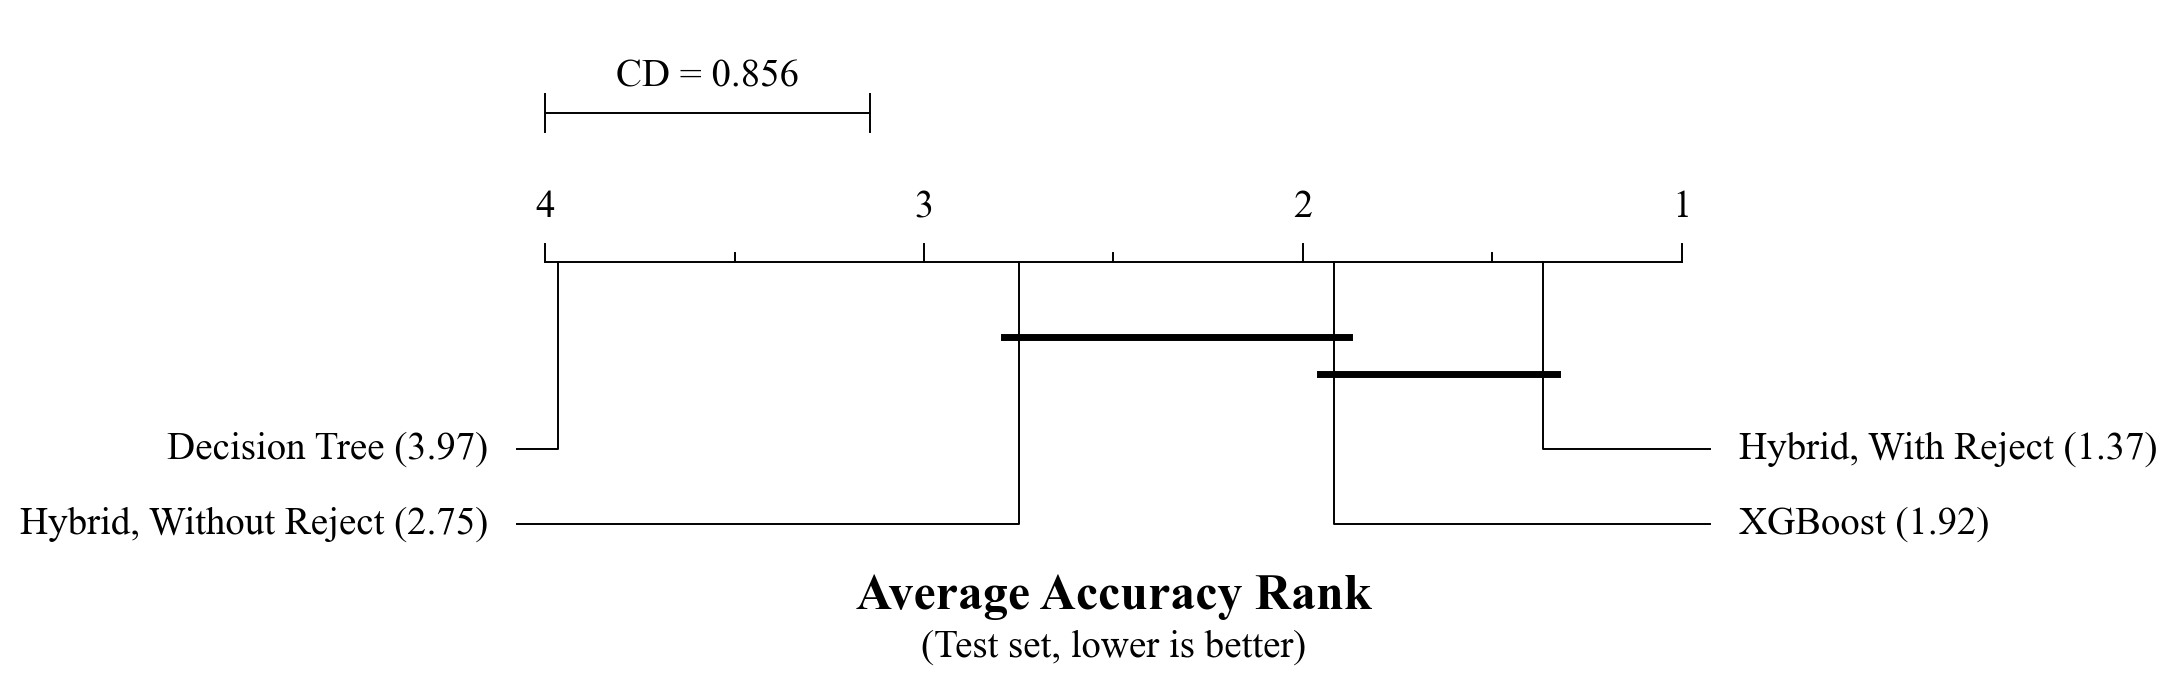

In [85]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
from autorank import autorank, plot_stats
from matplotlib import rcParams

plt.rcParams.update({
    'font.size': 14,          # Main text size (was default ~10)
    'axes.titlesize': 16,     # Title size (if you have one)
    'axes.labelsize': 14,     # Axis label size
    'xtick.labelsize': 12,    # The numbers on the axis (1.0, 2.0...)
    'ytick.labelsize': 12,
    'font.family': 'Times New Roman',
#    'font.family': 'sans-serif' # Optional: ensure a clean font
})

# 1. RENAME (Do this first!)
df_test_tmp = df_test.copy().rename(columns={
    "gb_accuracy": "Decision Tree (3.97)",
    "bb_accuracy": "XGBoost (1.92)",
    "hybrid_accuracy_no_reject": "Hybrid, Without Reject (2.75)",
    "hybrid_accuracy_w_reject": "Hybrid, With Reject (1.37)"
})

result = autorank(df_test_tmp, alpha=0.05, verbose=False)
create_report(result)

# 2. PLOT
fig, ax = plt.subplots(figsize=(11, 4))
plot_stats(result, ax=ax)

cd_value = result.cd

for text_obj in ax.texts:
    if text_obj.get_text() == 'CD':
        # Change text to "CD=0.123"
        text_obj.set_text(f"CD = {cd_value:.3f}")
        
# 3. REVERSE AXIS
# This puts Rank 1.0 on the left side
# ax.invert_xaxis()

# 4. MANUALLY ADD THE LABEL (The Fix)
# Since the bottom axis is hidden, we place text relative to the plot box.
# (0.5, -0.1) means: Center horizontally, and go 10% below the bottom edge.
ax.text(0.5, 0.10, "Average Accuracy Rank", 
        transform=ax.transAxes, 
        ha='center', va='top', fontsize=18, fontweight="bold")
ax.text(0.5, 0.01, "(Test set, lower is better)", 
        transform=ax.transAxes, 
        ha='center', va='top', fontsize=14)
# (Test set, lower is better)
#plt.show()
plt.savefig('../../figv2/out/cd_test_set.png')

In [86]:
# Print the raw p-value in scientific notation
print(f"Exact Friedman p-value: {result.pvalue:.5e}")

Exact Friedman p-value: 2.96251e-15
